# CMIP6 Case A — Step 2: Prepare the annual analysis dataset (1985–2014)

## 中文详细说明

本 notebook 将 Step 1 已确认的数据处理逻辑整理成可复现的年度数据产品。它不建立 tree，也不根据负 ET、零径流、ET>P 或水量残差删除网格。主要分析域是由模型固定场 `sftlf` 和 `sftgif` 定义的 **Non-ice land**。

处理目标：

1. 统一所有变量的经度和浮点坐标；
2. 使用月度时间边界把 P、ET、R 转为1985–2014逐年总量；
3. 建立稳定的 `grid_id`；
4. 生成4172个非冰盖网格 × 30年的 grid-year 面板；
5. 检查缺失、重复、年份完整性和年度水量残差；
6. 输出年度 NetCDF、气候态 Parquet 和年度面板 Parquet。

## English overview

This notebook converts the verified CMIP6 inputs into reproducible annual analysis products. It uses model-native land and land-ice masks, retains every non-ice grid cell, and performs no tree modelling. The outputs preserve both the 30-year climatology and the complete grid-by-year panel needed for later spatial and temporal analyses.


## Step 0 — Configuration, imports, and plotting style

### 中文说明

设置1985–2014研究时段、自动定位 `case/caseA`，并启用实际数据产品写出。输出只进入 `caseA/derived`，原始 NetCDF 不会被修改。

### English

Configure the 30-year period, locate Case A, and define a reproducible output directory. Original CMIP6 files remain read-only.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
})

START_YEAR = 1985
END_YEAR = 2014
WRITE_OUTPUTS = True

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(0.8)
    ax.tick_params(direction="out", length=3.5, width=0.7, color="#333333")
    ax.grid(True, color="#E5E7EB", linewidth=0.55, alpha=0.9, zorder=0)

CASE_DIR = find_case_dir()
OUTPUT_DIR = CASE_DIR / "derived"
print(f"Case directory: {CASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Period: {START_YEAR}–{END_YEAR}")


Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Output directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived
Period: 1985–2014


## Step 1 — Locate files and audit metadata

### 中文说明

严格要求 P、ET、R、`areacella`、`sftlf` 和 `sftgif` 各只有一个匹配文件。检查模型、成员、网格、单位和时间范围，防止不同 ensemble member 或网格版本被混合。`sftgif` 可以位于 `caseA` 根目录或 `sftgif/` 子目录。

### English

Locate exactly one file per required variable and audit model, ensemble member, grid label, units, shape, and temporal coverage before combining data.


In [2]:
def exactly_one_of(*patterns):
    matches = sorted({path for pattern in patterns for path in CASE_DIR.glob(pattern)})
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one match across {patterns}, found {len(matches)}: {matches}")
    return matches[0]

FILES = {
    "P": exactly_one_of("P/pr_*.nc"),
    "ET": exactly_one_of("ET/evspsbl_*.nc"),
    "R": exactly_one_of("Runoff/mrro_*.nc"),
    "area": exactly_one_of("areacella/areacella_*.nc"),
    "land": exactly_one_of("sftlf/sftlf_*.nc"),
    "ice": exactly_one_of("sftgif/sftgif_*.nc", "sftgif_*.nc"),
}
VAR_NAMES = {"P": "pr", "ET": "evspsbl", "R": "mrro", "area": "areacella", "land": "sftlf", "ice": "sftgif"}
DATASETS = {key: xr.open_dataset(path) for key, path in FILES.items()}

inventory_rows = []
for key, ds in DATASETS.items():
    da = ds[VAR_NAMES[key]]
    inventory_rows.append({
        "key": key, "file": FILES[key].name, "variable": VAR_NAMES[key],
        "units": da.attrs.get("units"), "shape": str(da.shape),
        "source_id": ds.attrs.get("source_id"), "variant": ds.attrs.get("variant_label"),
        "grid": ds.attrs.get("grid_label"),
        "time_start": str(ds.time.values[0])[:10] if "time" in ds.coords else "fixed",
        "time_end": str(ds.time.values[-1])[:10] if "time" in ds.coords else "fixed",
    })
inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

for field in ["source_id", "variant_label", "grid_label"]:
    values = {ds.attrs.get(field) for ds in DATASETS.values()}
    if len(values) != 1:
        raise ValueError(f"Metadata mismatch for {field}: {values}")


,key,file,variable,units,shape,source_id,variant,grid,time_start,time_end
0,P,pr_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_1...,pr,kg m-2 s-1,"(1980, 96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,1850-01-16,2014-12-16
1,ET,evspsbl_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1...,evspsbl,kg m-2 s-1,"(1980, 96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,1850-01-16,2014-12-16
2,R,mrro_Lmon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn...,mrro,kg m-2 s-1,"(1980, 96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,1850-01-16,2014-12-16
3,area,areacella_fx_MPI-ESM1-2-LR_historical_r1i1p1f1...,areacella,m2,"(96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,fixed,fixed
4,land,sftlf_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc,sftlf,%,"(96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,fixed,fixed
5,ice,sftgif_fx_MPI-ESM1-2-LR_historical_r1i1p1f1_gn.nc,sftgif,%,"(96, 192)",MPI-ESM1-2-LR,r1i1p1f1,gn,fixed,fixed


## Step 2 — Normalize coordinates and construct model-native masks

### 中文说明

所有经度先统一为 $[-180,180)$ 并排序，再使用 `np.allclose` 验证网格兼容。这里明确建立 All land、Non-ice land 和 Land ice；年度主数据只保留 Non-ice land，但原始数组不被改写。

### English

Normalize longitudes before xarray alignment, verify coordinate compatibility, and construct model-native land, non-ice-land, and land-ice masks.


In [3]:
def normalize_longitude(da):
    if "lon" not in da.coords:
        return da
    return da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

sftlf = normalize_longitude(DATASETS["land"]["sftlf"])
sftgif = normalize_longitude(DATASETS["ice"]["sftgif"])
areacella = normalize_longitude(DATASETS["area"]["areacella"])
ref_lat, ref_lon = sftlf.lat, sftlf.lon

def harmonize(da, name):
    da = normalize_longitude(da)
    if da.sizes.get("lat") != ref_lat.size or da.sizes.get("lon") != ref_lon.size:
        raise ValueError(f"{name}: horizontal shape mismatch.")
    if not np.allclose(da.lat, ref_lat, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: latitude grid mismatch.")
    if not np.allclose(da.lon, ref_lon, atol=1e-10, rtol=0):
        raise ValueError(f"{name}: longitude grid mismatch.")
    return da.assign_coords(lat=ref_lat, lon=ref_lon)

P_flux = harmonize(DATASETS["P"]["pr"], "P")
ET_flux = harmonize(DATASETS["ET"]["evspsbl"], "ET")
R_flux = harmonize(DATASETS["R"]["mrro"], "R")
areacella = harmonize(areacella, "areacella")
sftgif = harmonize(sftgif, "sftgif")

land_mask = sftlf > 0
ice_mask = land_mask & (sftgif > 0)
non_ice_mask = land_mask & ~ice_mask
land_area = (areacella * sftlf / 100).where(land_mask, 0).rename("land_area")

mask_audit = pd.Series({
    "all_land_cells": int(land_mask.sum()),
    "non_ice_land_cells": int(non_ice_mask.sum()),
    "land_ice_cells": int(ice_mask.sum()),
    "all_land_area_million_km2": float(land_area.sum() / 1e12),
    "non_ice_area_million_km2": float(land_area.where(non_ice_mask, 0).sum() / 1e12),
    "land_ice_area_million_km2": float((areacella * sftgif / 100).where(ice_mask, 0).sum() / 1e12),
})
display(mask_audit.to_frame("value"))


,value
all_land_cells,6222.000000
non_ice_land_cells,4172.000000
land_ice_cells,2050.000000
all_land_area_million_km2,147.102076
non_ice_area_million_km2,131.334329
land_ice_area_million_km2,15.767745


## Step 3 — Convert monthly fluxes to annual totals

### 中文说明

使用每个月的 `time_bnds` 计算真实秒数，将 `kg m⁻² s⁻¹` 转为 `mm/month`，再按年求和。生成 P、ET、R、$WB=P-ET-R$ 以及所有 P>0 局地网格的 ET/P、R/P。

### English

Use exact monthly time bounds to convert fluxes to annual water-depth totals. Derived annual variables retain the full local non-ice domain without precipitation thresholds.


In [4]:
def annual_totals_from_flux(da, ds):
    selected = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))
    bounds = ds["time_bnds"].sel(time=selected.time)
    seconds = (bounds.isel(bnds=1) - bounds.isel(bnds=0)) / np.timedelta64(1, "s")
    if selected.sizes["time"] != (END_YEAR - START_YEAR + 1) * 12:
        raise ValueError("Selected period does not contain exactly 360 months.")
    annual = (selected * seconds).groupby("time.year").sum("time", skipna=False)
    if not np.all(selected.time.groupby("time.year").count().values == 12):
        raise ValueError("At least one year does not contain 12 months.")
    return annual.astype("float32")

P_annual = annual_totals_from_flux(P_flux, DATASETS["P"]).rename("P")
ET_annual = annual_totals_from_flux(ET_flux, DATASETS["ET"]).rename("ET")
R_annual = annual_totals_from_flux(R_flux, DATASETS["R"]).rename("R")
WB_annual = (P_annual - ET_annual - R_annual).rename("WB")
RATIO_MIN_P_MM_YR = 1.0
ET_over_P_annual = xr.where(P_annual > RATIO_MIN_P_MM_YR, ET_annual / P_annual, np.nan).astype("float32").rename("ET_over_P")
R_over_P_annual = xr.where(P_annual > RATIO_MIN_P_MM_YR, R_annual / P_annual, np.nan).astype("float32").rename("R_over_P")

for da in [P_annual, ET_annual, R_annual, WB_annual]:
    da.attrs.update({"units": "mm yr-1", "analysis_period": f"{START_YEAR}-{END_YEAR}"})
ET_over_P_annual.attrs.update({"units": "1", "valid_where": "P > 1 mm yr-1"})
R_over_P_annual.attrs.update({"units": "1", "valid_where": "P > 1 mm yr-1"})

grid_id_values = np.full(non_ice_mask.shape, -1, dtype="int32")
grid_id_values[non_ice_mask.values] = np.arange(1, int(non_ice_mask.sum()) + 1, dtype="int32")
grid_id = xr.DataArray(grid_id_values, coords={"lat": ref_lat, "lon": ref_lon}, dims=("lat", "lon"), name="grid_id")
grid_id.attrs.update({"long_name": "stable non-ice land grid identifier", "string_format": "MPI_LR_{grid_id:06d}", "missing_value": -1})

annual_ds = xr.Dataset({
    "P": P_annual.where(non_ice_mask), "ET": ET_annual.where(non_ice_mask),
    "R": R_annual.where(non_ice_mask), "WB": WB_annual.where(non_ice_mask),
    "ET_over_P": ET_over_P_annual.where(non_ice_mask),
    "R_over_P": R_over_P_annual.where(non_ice_mask),
    "grid_id": grid_id, "analysis_cell": non_ice_mask.astype("int8"),
    "land_fraction": sftlf.astype("float32"),
    "land_ice_fraction": sftgif.astype("float32"),
    "cell_area": areacella, "land_area": land_area,
})
annual_ds.attrs.update({
    "title": "MPI-ESM1-2-LR annual non-ice terrestrial water-cycle dataset",
    "source_id": DATASETS["P"].attrs.get("source_id"),
    "variant_label": DATASETS["P"].attrs.get("variant_label"),
    "grid_label": DATASETS["P"].attrs.get("grid_label"),
    "experiment_id": DATASETS["P"].attrs.get("experiment_id"),
    "analysis_period": f"{START_YEAR}-{END_YEAR}",
    "analysis_domain": "non-ice land defined by sftlf > 0 and sftgif == 0",
})
print(annual_ds)


<xarray.Dataset> Size: 14MB
Dimensions:            (lat: 96, lon: 192, year: 30)
Coordinates:
  * lat                (lat) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * lon                (lon) float64 2kB -180.0 -178.1 -176.2 ... 176.2 178.1
  * year               (year) int64 240B 1985 1986 1987 1988 ... 2012 2013 2014
Data variables:
    P                  (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    ET                 (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    R                  (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    WB                 (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    ET_over_P          (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    R_over_P           (year, lat, lon) float32 2MB nan nan nan ... nan nan nan
    grid_id            (lat, lon) int32 74kB -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1
    analysis_cell      (lat, lon) int8 18kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    land_fract

## Step 4 — Build climatology and grid-year tables

### 中文说明

气候态表每个 `grid_id` 一行，共4172行；年度面板每个 `grid_id + year` 一行，预期125,160行。字符串 `grid_id` 由固定的空间顺序生成，因此重复执行仍保持一致。

### English

Construct one-row-per-grid climatology and one-row-per-grid-year annual panel tables. The stable identifier is deterministic and independent of floating-point coordinate joins.


In [5]:
annual_variables = ["P", "ET", "R", "WB", "ET_over_P", "R_over_P"]
climatology_ds = annual_ds[annual_variables].mean("year", keep_attrs=True)
for name in ["grid_id", "analysis_cell", "land_fraction", "land_ice_fraction", "cell_area", "land_area"]:
    climatology_ds[name] = annual_ds[name]
climatology_ds.attrs.update(annual_ds.attrs)
climatology_ds.attrs["temporal_aggregation"] = "mean of annual totals, 1985-2014"

climatology_df = climatology_ds.to_dataframe().reset_index()
climatology_df = climatology_df.loc[climatology_df["analysis_cell"] == 1].copy()
climatology_df["grid_id_numeric"] = climatology_df["grid_id"].astype("int32")
climatology_df["grid_id"] = climatology_df["grid_id_numeric"].map(lambda value: f"MPI_LR_{value:06d}")
climatology_df["surface_class"] = "Non-ice land"
climatology_df["negative_ET"] = climatology_df["ET"] < 0
climatology_df["zero_R"] = climatology_df["R"] == 0
climatology_df["ET_greater_than_P"] = climatology_df["ET"] > climatology_df["P"]
climatology_df["large_WB"] = climatology_df["WB"].abs() > 10
climatology_df = climatology_df.sort_values("grid_id_numeric").reset_index(drop=True)

annual_df = annual_ds.to_dataframe().reset_index()
annual_df = annual_df.loc[annual_df["analysis_cell"] == 1].copy()
annual_df["grid_id_numeric"] = annual_df["grid_id"].astype("int32")
annual_df["grid_id"] = annual_df["grid_id_numeric"].map(lambda value: f"MPI_LR_{value:06d}")
annual_df["surface_class"] = "Non-ice land"
annual_df["negative_ET"] = annual_df["ET"] < 0
annual_df["zero_R"] = annual_df["R"] == 0
annual_df["ET_greater_than_P"] = annual_df["ET"] > annual_df["P"]
annual_df["large_WB"] = annual_df["WB"].abs() > 10
annual_df = annual_df.sort_values(["grid_id_numeric", "year"]).reset_index(drop=True)

display(climatology_df.head())
display(annual_df.head())


,lat,lon,P,ET,R,WB,ET_over_P,R_over_P,grid_id,analysis_cell,land_fraction,land_ice_fraction,cell_area,land_area,grid_id_numeric,surface_class,negative_ET,zero_R,ET_greater_than_P,large_WB
0,-55.024808,-69.375,1283.296997,600.391846,682.761658,0.143772,0.468685,0.531193,MPI_LR_000001,1,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,False
1,-55.024808,-67.500,1050.722900,581.723572,468.916809,0.082620,0.554586,0.445514,MPI_LR_000002,1,100.0,0.0,2.478351e+10,2.478351e+10,2,Non-ice land,False,False,False,False
2,-53.159595,-73.125,1668.252197,734.953918,933.258911,0.039414,0.441730,0.558210,MPI_LR_000003,1,100.0,0.0,2.592378e+10,2.592378e+10,3,Non-ice land,False,False,False,False
3,-53.159595,-71.250,1370.924194,791.946716,578.165771,0.811759,0.579140,0.420277,MPI_LR_000004,1,100.0,0.0,2.592378e+10,2.592378e+10,4,Non-ice land,False,False,False,False
4,-53.159595,-69.375,1084.410400,933.373962,151.007339,0.028970,0.863477,0.137207,MPI_LR_000005,1,100.0,0.0,2.592378e+10,2.592378e+10,5,Non-ice land,False,False,False,False


,lat,lon,year,P,ET,R,WB,ET_over_P,R_over_P,grid_id,...,land_fraction,land_ice_fraction,cell_area,land_area,grid_id_numeric,surface_class,negative_ET,zero_R,ET_greater_than_P,large_WB
0,-55.024808,-69.375,1985,1255.648071,592.471802,653.036804,10.139465,0.471845,0.520079,MPI_LR_000001,...,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,True
1,-55.024808,-69.375,1986,1217.334839,600.072632,623.895752,-6.633545,0.492940,0.512510,MPI_LR_000001,...,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,False
2,-55.024808,-69.375,1987,1153.081665,604.053284,546.148254,2.880127,0.523860,0.473642,MPI_LR_000001,...,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,False
3,-55.024808,-69.375,1988,1421.328369,661.587036,759.647095,0.094238,0.465471,0.534463,MPI_LR_000001,...,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,False
4,-55.024808,-69.375,1989,1271.539551,611.231018,673.804382,-13.495850,0.480702,0.529912,MPI_LR_000001,...,100.0,0.0,2.478351e+10,2.478351e+10,1,Non-ice land,False,False,False,True


## Step 5 — Completeness, uniqueness, and consistency checks

### 中文说明

检查每个网格是否恰好有30年、`grid_id + year` 是否唯一、主变量是否缺失，以及年度表按年平均后能否精确重现气候态表。任一关键检查失败都会主动报错，避免把不完整数据写出。

### English

Verify row counts, unique grid-year keys, 30 complete years per grid, missing values, and exact agreement between annual-panel means and climatological fields.


In [6]:
expected_grids = int(non_ice_mask.sum())
expected_years = END_YEAR - START_YEAR + 1
expected_rows = expected_grids * expected_years
years_per_grid = annual_df.groupby("grid_id")["year"].nunique()
duplicate_keys = int(annual_df.duplicated(["grid_id", "year"]).sum())
missing_primary = int(annual_df[["P", "ET", "R", "WB"]].isna().any(axis=1).sum())
panel_means = annual_df.groupby("grid_id")[annual_variables].mean().sort_index()
clim_means = climatology_df.set_index("grid_id")[annual_variables].sort_index()
climatology_difference = (panel_means - clim_means).abs().max()
max_climatology_difference = float(climatology_difference.max())

qc_summary = pd.Series({
    "expected_non_ice_grids": expected_grids,
    "climatology_rows": len(climatology_df),
    "expected_grid_year_rows": expected_rows,
    "actual_grid_year_rows": len(annual_df),
    "duplicate_grid_year_keys": duplicate_keys,
    "minimum_years_per_grid": int(years_per_grid.min()),
    "maximum_years_per_grid": int(years_per_grid.max()),
    "missing_primary_rows": missing_primary,
    "max_panel_vs_climatology_difference": max_climatology_difference,
})
display(qc_summary.to_frame("value"))
display(climatology_difference.rename("maximum absolute difference").to_frame())

assert len(climatology_df) == expected_grids
assert len(annual_df) == expected_rows
assert duplicate_keys == 0
assert years_per_grid.min() == expected_years and years_per_grid.max() == expected_years
assert missing_primary == 0
assert max_climatology_difference < 1e-3  # float32 aggregation tolerance


,value
expected_non_ice_grids,4172.000000
climatology_rows,4172.000000
expected_grid_year_rows,125160.000000
actual_grid_year_rows,125160.000000
duplicate_grid_year_keys,0.000000
minimum_years_per_grid,30.000000
maximum_years_per_grid,30.000000
missing_primary_rows,0.000000
max_panel_vs_climatology_difference,0.000732


,maximum absolute difference
P,7.324219e-04
ET,4.882812e-04
R,3.662109e-04
WB,7.629395e-06
ET_over_P,3.576279e-07
R_over_P,2.384186e-07


## Step 6 — Diagnose annual and persistent water-balance residuals

### 中文说明

长期残差超过10 mm/year的网格不会被删除。这里分别检查其30年平均、年际标准差、最大绝对年度残差以及正残差年份比例，用来判断偏差是持续存在还是由少数年份造成。

### English

Retain and characterize every residual flag. Compare the long-term mean with interannual variability, the maximum annual magnitude, and sign persistence.


,lat,lon,WB_mean,WB_std,WB_max_abs,positive_year_fraction,P_mean,grid_id,grid_id_numeric,relative_WB_percent
12719,34.507,-91.875,-30.455999,144.001999,326.809998,0.467,1172.691040,MPI_LR_001902,1902,-2.597
8517,-6.528,-50.625,29.716999,167.035995,345.537994,0.567,1728.753052,MPI_LR_000694,694,1.719
12910,36.372,-93.750,-29.204000,150.061996,329.010010,0.467,1014.286011,MPI_LR_001983,1983,-2.879
12911,36.372,-91.875,-24.638000,145.531006,267.612000,0.400,1056.134033,MPI_LR_001984,1984,-2.333
13101,38.238,-95.625,-19.350000,78.012001,197.225998,0.333,971.992981,MPI_LR_002063,2063,-1.991
10076,8.394,-7.500,18.612000,72.166000,165.996002,0.600,1229.501953,MPI_LR_001030,1030,1.514
9950,6.528,116.250,18.214001,180.248993,425.947998,0.467,1870.862061,MPI_LR_001015,1015,0.974
7370,-17.720,-41.250,18.197001,134.496994,413.207001,0.433,1390.452026,MPI_LR_000448,448,1.309
6789,-23.316,-50.625,18.070999,132.022995,317.881989,0.600,1283.474976,MPI_LR_000302,302,1.408
10328,10.259,105.000,17.444000,225.852005,467.059998,0.533,1491.467041,MPI_LR_001109,1109,1.170


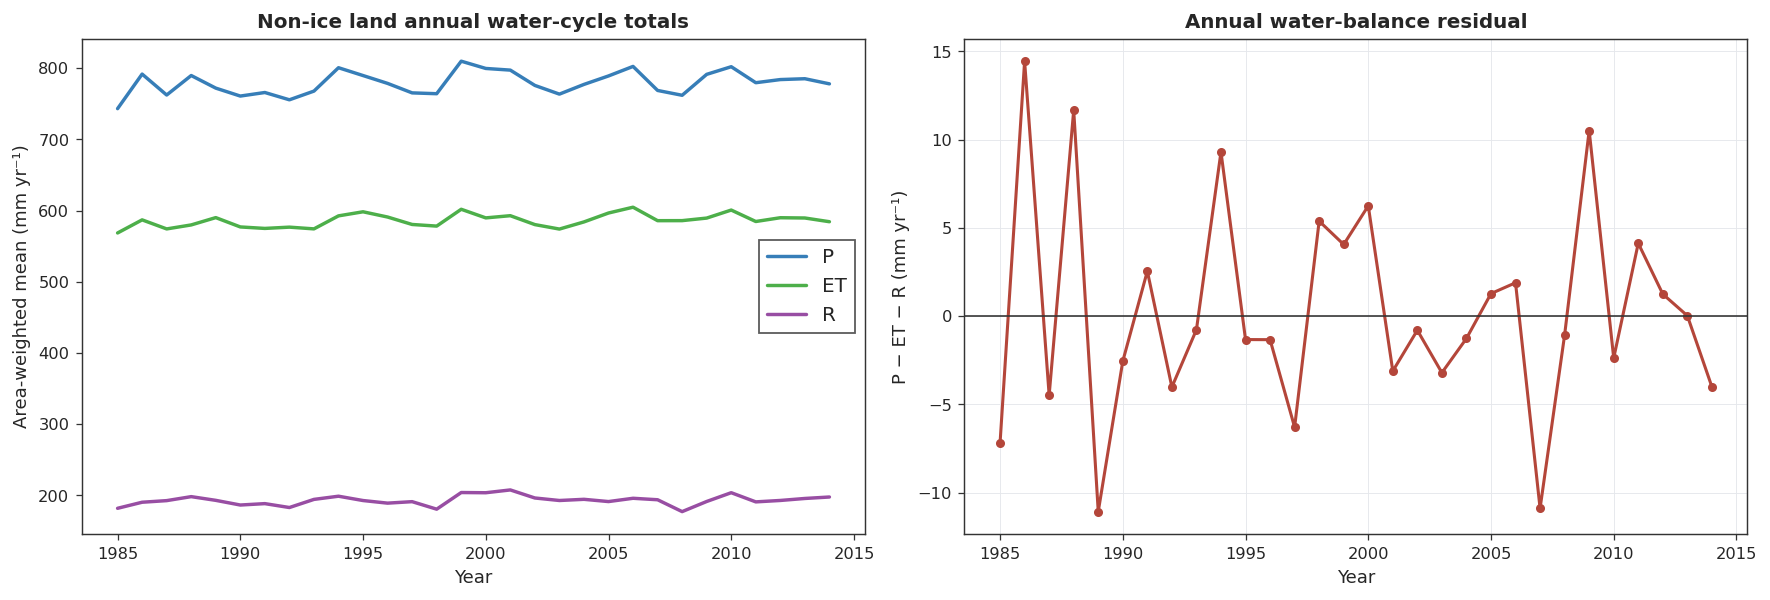

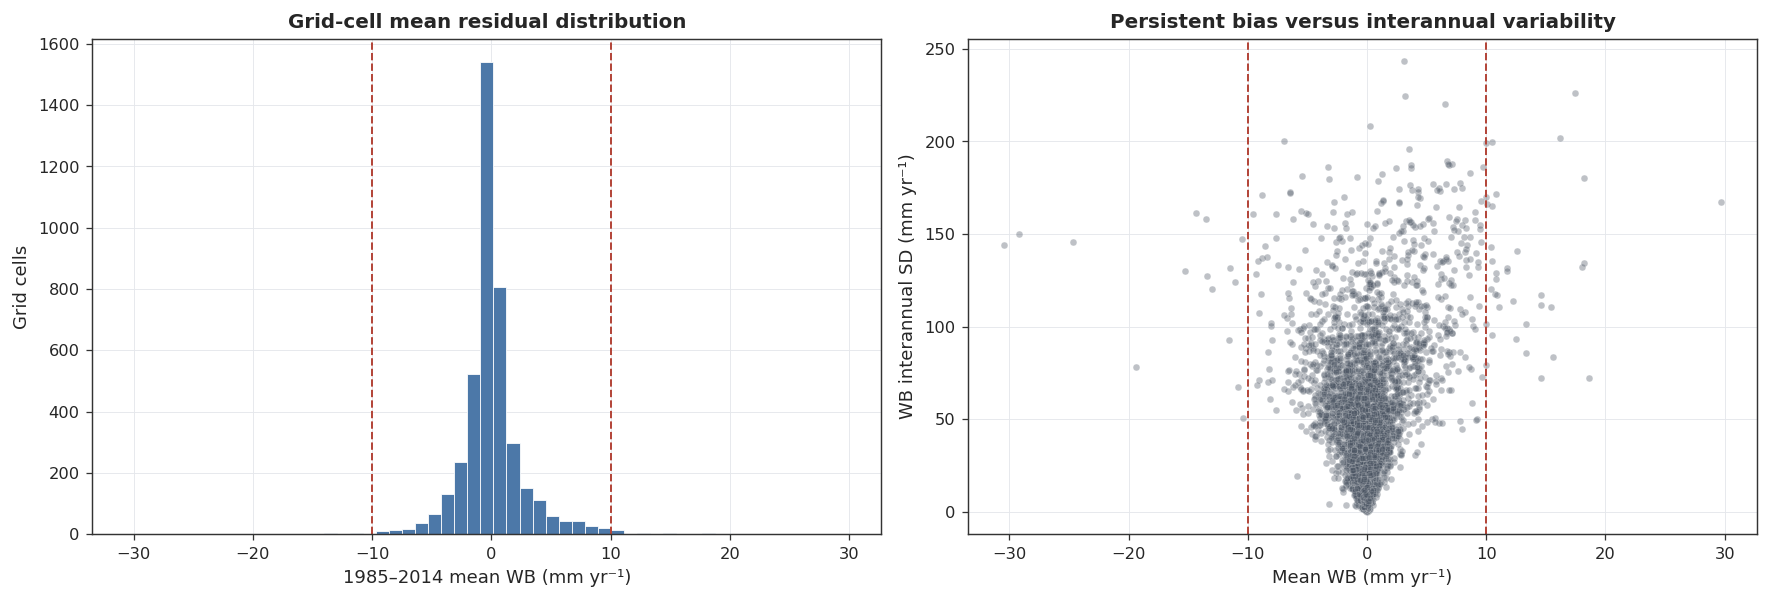

In [7]:
weights = land_area.where(non_ice_mask, 0)
def area_weighted_mean(da):
    return (da.where(non_ice_mask) * weights).sum(("lat", "lon"), skipna=True) / weights.sum()

annual_global = pd.DataFrame({
    "P": area_weighted_mean(P_annual).to_series(),
    "ET": area_weighted_mean(ET_annual).to_series(),
    "R": area_weighted_mean(R_annual).to_series(),
    "WB": area_weighted_mean(WB_annual).to_series(),
})

residual_diagnostics = xr.Dataset({
    "WB_mean": WB_annual.mean("year"),
    "WB_std": WB_annual.fillna(0).std("year").where(non_ice_mask),
    "WB_max_abs": np.abs(WB_annual).max("year"),
    "positive_year_fraction": (WB_annual > 0).mean("year"),
    "P_mean": P_annual.mean("year"),
    "grid_id": grid_id,
}).where(non_ice_mask)
residual_df = residual_diagnostics.to_dataframe().reset_index().dropna(subset=["WB_mean"])
residual_df["grid_id_numeric"] = residual_df["grid_id"].astype("int32")
residual_df["grid_id"] = residual_df["grid_id_numeric"].map(lambda value: f"MPI_LR_{value:06d}")
residual_df["relative_WB_percent"] = 100 * residual_df["WB_mean"] / residual_df["P_mean"]
persistent_flags = residual_df.loc[residual_df["WB_mean"].abs() > 10].copy()
persistent_flags = persistent_flags.sort_values("WB_mean", key=np.abs, ascending=False)
display(persistent_flags.head(20).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
for ax in axes:
    style_axes(ax)
annual_global[["P", "ET", "R"]].plot(ax=axes[0], lw=1.9, color=["#377EB8", "#4DAF4A", "#984EA3"])
axes[0].set_title("Non-ice land annual water-cycle totals")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Area-weighted mean (mm yr⁻¹)")
axes[0].legend(frameon=True, fancybox=False, edgecolor="#333333")
axes[1].plot(annual_global.index, annual_global["WB"], color="#B4463A", marker="o", ms=4, lw=1.7)
axes[1].axhline(0, color="#333333", lw=0.9)
axes[1].set_title("Annual water-balance residual")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("P − ET − R (mm yr⁻¹)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
for ax in axes:
    style_axes(ax)
axes[0].hist(residual_df["WB_mean"], bins=55, color="#4C78A8", edgecolor="white", linewidth=0.45)
axes[0].axvline(-10, color="#B4463A", ls="--", lw=1.1)
axes[0].axvline(10, color="#B4463A", ls="--", lw=1.1)
axes[0].set_title("Grid-cell mean residual distribution")
axes[0].set_xlabel("1985–2014 mean WB (mm yr⁻¹)")
axes[0].set_ylabel("Grid cells")
axes[1].scatter(residual_df["WB_mean"], residual_df["WB_std"], s=14, alpha=0.36, color="#4B5563", edgecolors="white", linewidths=0.2, rasterized=True)
axes[1].axvline(-10, color="#B4463A", ls="--", lw=1.1)
axes[1].axvline(10, color="#B4463A", ls="--", lw=1.1)
axes[1].set_title("Persistent bias versus interannual variability")
axes[1].set_xlabel("Mean WB (mm yr⁻¹)")
axes[1].set_ylabel("WB interannual SD (mm yr⁻¹)")
plt.show()


## Step 7 — Write standardized NetCDF and Parquet products

### 中文说明

年度 NetCDF 保留规则经纬度结构，非分析网格为缺失；Parquet 表仅包含4172个非冰盖网格。写出后立即重新打开，核对维度、行数、唯一键和文件大小。

### English

Write compressed, standardized products and immediately reopen them for structural validation.


In [8]:
NETCDF_PATH = OUTPUT_DIR / f"MPI_ESM1_2_LR_water_cycle_annual_{START_YEAR}_{END_YEAR}.nc"
CLIMATOLOGY_PATH = OUTPUT_DIR / f"MPI_ESM1_2_LR_water_cycle_climatology_{START_YEAR}_{END_YEAR}.parquet"
GRID_YEAR_PATH = OUTPUT_DIR / f"MPI_ESM1_2_LR_water_cycle_grid_year_{START_YEAR}_{END_YEAR}.parquet"

if WRITE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    float_encoding = {
        name: {"zlib": True, "complevel": 4, "shuffle": True, "dtype": "float32"}
        for name in ["P", "ET", "R", "WB", "ET_over_P", "R_over_P", "land_fraction", "land_ice_fraction"]
    }
    area_encoding = {name: {"zlib": True, "complevel": 4, "shuffle": True} for name in ["cell_area", "land_area"]}
    annual_ds.to_netcdf(NETCDF_PATH, engine="netcdf4", encoding={**float_encoding, **area_encoding})
    climatology_df.to_parquet(CLIMATOLOGY_PATH, index=False, compression="zstd")
    annual_df.to_parquet(GRID_YEAR_PATH, index=False, compression="zstd")
else:
    print("WRITE_OUTPUTS=False: validation ran, but no files were written.")

if WRITE_OUTPUTS:
    reopened_nc = xr.open_dataset(NETCDF_PATH)
    reopened_clim = pd.read_parquet(CLIMATOLOGY_PATH)
    reopened_panel = pd.read_parquet(GRID_YEAR_PATH)
    if reopened_nc.sizes["year"] != expected_years:
        raise ValueError("Reopened NetCDF year dimension is incorrect.")
    if len(reopened_clim) != expected_grids:
        raise ValueError("Reopened climatology row count is incorrect.")
    if len(reopened_panel) != expected_rows or reopened_panel.duplicated(["grid_id", "year"]).any():
        raise ValueError("Reopened annual panel failed row-count or key-uniqueness validation.")
    output_manifest = pd.DataFrame([
        {"product": "annual NetCDF", "path": str(NETCDF_PATH), "rows_or_years": reopened_nc.sizes["year"], "size_MB": NETCDF_PATH.stat().st_size / 1e6},
        {"product": "climatology Parquet", "path": str(CLIMATOLOGY_PATH), "rows_or_years": len(reopened_clim), "size_MB": CLIMATOLOGY_PATH.stat().st_size / 1e6},
        {"product": "grid-year Parquet", "path": str(GRID_YEAR_PATH), "rows_or_years": len(reopened_panel), "size_MB": GRID_YEAR_PATH.stat().st_size / 1e6},
    ])
    display(output_manifest.round({"size_MB": 3}))
    reopened_nc.close()


,product,path,rows_or_years,size_MB
0,annual NetCDF,/Users/mimi/Documents/Code/Github/GSA-work/exp...,30,3.209
1,climatology Parquet,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4172,0.170
2,grid-year Parquet,/Users/mimi/Documents/Code/Github/GSA-work/exp...,125160,4.312


## Step 8 — Completion checklist

### 中文说明

完成标准：4172个非冰盖网格、每格30年、125,160个唯一 grid-year、主变量无缺失、年度均值与气候态一致、三个派生文件均能重新打开。只有这些条件全部满足，年度数据处理才算完成。

### English

Processing is complete only when all expected grids and years are present, keys are unique, primary variables are complete, climatological consistency is verified, and every written product reopens successfully.
